In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
pip install wfdb torch_geometric neurokit2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 26.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [3]:
#preprocessing

import numpy as np
import pandas as pd
import wfdb
import neurokit2 as nk
from scipy.signal import resample
import os
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# --- Configuration ---
# Make sure these paths point to your dataset location
ECG_FOLDER = '/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/'
METADATA_FILE = '/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/ptbxl_database.csv'
OUTPUT_FILE = 'ptbxl_database_with_features.csv'
TARGET_SAMPLING_RATE = 100

# --- Clinical Feature Extractor ---
class ClinicalFeatureExtractor:
    """Extracts clinically-relevant features from an ECG signal."""
    def __init__(self, sampling_rate=100):
        self.sampling_rate = sampling_rate

    def __call__(self, signal: np.ndarray) -> np.ndarray:
        try:
            _, rpeaks = nk.ecg_peaks(signal, sampling_rate=self.sampling_rate)
            if rpeaks['ECG_R_Peaks'].size < 2:
                return np.zeros(3, dtype=np.float32)

            hr = nk.hrv_time(rpeaks, sampling_rate=self.sampling_rate)['HRV_MeanNN'][0] / 1000.0
            _, waves = nk.ecg_delineate(signal, rpeaks, sampling_rate=self.sampling_rate)
            
            qrs_duration = np.nanmean(waves['ECG_QRS_Offsets'] - waves['ECG_QRS_Onsets']) / self.sampling_rate
            qt_interval = np.nanmean(waves['ECG_T_Offsets'] - waves['ECG_Q_Onsets']) / self.sampling_rate
            
            features = [hr, qrs_duration, qt_interval]
            return np.nan_to_num(features, nan=0.0).astype(np.float32)
        except Exception:
            return np.zeros(3, dtype=np.float32)

def normalize_signal(signal: np.ndarray) -> np.ndarray:
    """Normalizes a signal."""
    std = np.std(signal)
    return (signal - np.mean(signal)) / (std + 1e-8) if std > 1e-8 else signal

def process_signal(signal: np.ndarray, original_sr: int, target_sr: int) -> np.ndarray:
    """Resamples and normalizes a signal."""
    if original_sr != target_sr:
        num_samples = int(signal.shape[0] * target_sr / original_sr)
        signal = resample(signal, num_samples)
    return normalize_signal(signal)

def main():
    """
    Main function to run the pre-processing pipeline.
    """
    print(f"Loading metadata from {METADATA_FILE}...")
    df = pd.read_csv(METADATA_FILE)
    
    feature_extractor = ClinicalFeatureExtractor(sampling_rate=TARGET_SAMPLING_RATE)
    
    all_clinical_features = []
    
    print("Starting feature extraction for all ECG records...")
    # Use tqdm for a progress bar
    for _, row in tqdm(df.iterrows(), total=df.shape[0]):
        try:
            # Load the high-resolution signal
            rec_path = os.path.join(ECG_FOLDER, row['filename_hr'])
            sig, meta = wfdb.rdsamp(rec_path)
            
            # Use Lead II (index 1) for feature extraction, as is standard
            lead_ii_signal = sig[:, 1]
            
            # Resample and normalize the signal before feature extraction
            processed_lead_ii = process_signal(lead_ii_signal, meta['fs'], TARGET_SAMPLING_RATE)
            
            # Extract features
            clinical_features = feature_extractor(processed_lead_ii)
            all_clinical_features.append(clinical_features)
            
        except Exception as e:
            print(f"Warning: Could not process record {row['ecg_id']}. Error: {e}. Appending zeros.")
            all_clinical_features.append(np.zeros(3, dtype=np.float32))

    # Add the new features to the DataFrame
    features_df = pd.DataFrame(all_clinical_features, columns=['heart_rate', 'qrs_duration', 'qt_interval'])
    df_with_features = pd.concat([df, features_df], axis=1)
    
    # Save the new DataFrame to a CSV file
    print(f"\nFeature extraction complete. Saving to {OUTPUT_FILE}...")
    df_with_features.to_csv(OUTPUT_FILE, index=False)
    
    print("Pre-processing finished successfully!")

if __name__ == "__main__":
    main()

Loading metadata from /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/ptbxl_database.csv...
Starting feature extraction for all ECG records...


100%|██████████| 21837/21837 [42:07<00:00,  8.64it/s]



Feature extraction complete. Saving to ptbxl_database_with_features.csv...
Pre-processing finished successfully!


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import SAGEConv, GATConv, global_mean_pool
import wfdb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample
import ast
import os
import json
import yaml
import pickle
from tqdm import tqdm
from typing import Dict, Any, Tuple, Optional, Union
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. Configuration Management
# =============================================================================
class Config:
    """
    Centralized configuration class with the best hyperparameters found by Optuna.
    """
    DEFAULT_CONFIG = {
        'data': {
            'ecg_folder': '/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/',
            'metadata_file': 'ptbxl_database_with_features.csv',
            'scp_file': '/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/scp_statements.csv',
            'test_size': 0.2, 'val_size': 0.1, 'random_state': 42,
            'target_sampling_rate': 100, 'signal_length': 1000
        },
        'model': {
            'cnn_out_dim': 48, 'gnn_hidden': 48, 'clinical_feature_dim': 16,
            'cnn_channels': [8, 16, 32, 64],
            # --- OPTIMIZED PARAMETERS ---
            'dropout_rate': 0.2890765335597656,
            'num_gnn_layers': 2, 
            'use_attention': True, 
            'attention_heads': 2
            # --------------------------
        },
        'training': {
            'batch_size': 64, 
            # --- OPTIMIZED PARAMETERS ---
            'learning_rate': 0.004419605206277622, 
            'weight_decay': 0.001796596866956301,
            # --------------------------
            'epochs': 50, 'gradient_clip': 1.0, 'scheduler_patience': 7, 
            'scheduler_factor': 0.5, 'mixed_precision': True, 'early_stopping_patience': 15
        },
        'augmentation': {
            'lead_dropout_prob': 0.1, 'noise_std': 0.02,
            'amplitude_scale_range': [0.9, 1.1], 'time_shift_range': [-50, 50],
            'enable_augmentation': True
        }
    }
    
    def __init__(self, config_dict: Optional[Dict] = None):
        self.config = self.DEFAULT_CONFIG.copy()
        if config_dict: self._deep_update(self.config, config_dict)
    
    def _deep_update(self, base: Dict, update: Dict):
        for key, value in update.items():
            if isinstance(base.get(key), dict) and isinstance(value, dict): self._deep_update(base[key], value)
            else: base[key] = value
    
    def get(self, key_path: str, default=None):
        keys = key_path.split('.'); current = self.config
        for key in keys:
            current = current.get(key) if isinstance(current, dict) else default
            if current is None: return default
        return current

# =============================================================================
# 2. Data Processing, Model, and Trainer Definitions
# (These sections remain the same as the previous script)
# =============================================================================
class SignalProcessor:
    @staticmethod
    def create_anatomical_adjacency() -> torch.Tensor:
        relationships = [(0, 1), (0, 4), (1, 2), (1, 5), (2, 5), (3, 4), (3, 0), (4, 5), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), (1, 6), (5, 10), (4, 11)]
        edges = [[i, j] for i, j in relationships] + [[j, i] for i, j in relationships]
        unique_edges = list(set(tuple(sorted(e)) for e in edges))
        return torch.tensor(unique_edges, dtype=torch.long).t().contiguous()
    @staticmethod
    def normalize_signal(signal: np.ndarray) -> np.ndarray:
        std = np.std(signal); return (signal - np.mean(signal)) / (std + 1e-8) if std > 1e-8 else signal

class ECGAugmenter:
    def __init__(self, config: Config): self.config = config
    def __call__(self, signals: np.ndarray, enable: bool = True) -> np.ndarray:
        if not enable: return signals
        if np.random.random() < 0.5: signals = self._add_noise(signals)
        if np.random.random() < 0.3: signals = self._scale_amplitude(signals)
        if np.random.random() < 0.3: signals = self._time_shift(signals)
        if np.random.random() < self.config.get('augmentation.lead_dropout_prob'): signals = self._lead_dropout(signals)
        return signals
    def _add_noise(self, signals: np.ndarray) -> np.ndarray: return signals + np.random.normal(0, self.config.get('augmentation.noise_std'), signals.shape)
    def _scale_amplitude(self, signals: np.ndarray) -> np.ndarray: return signals * np.random.uniform(*self.config.get('augmentation.amplitude_scale_range'))
    def _time_shift(self, signals: np.ndarray) -> np.ndarray:
        shift = np.random.randint(*self.config.get('augmentation.time_shift_range')); return np.roll(signals, shift, axis=-1)
    def _lead_dropout(self, signals: np.ndarray) -> np.ndarray:
        signals = signals.copy(); signals[np.random.choice(12, size=np.random.randint(1, 3), replace=False)] = 0
        return signals

class PTBXLGraphDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, config: Config, split: str = 'train'):
        self.meta, self.config, self.split = meta_df, config, split
        self.ecg_folder = config.get('data.ecg_folder')
        self.target_sr = config.get('data.target_sampling_rate')
        self.signal_length = config.get('data.signal_length')
        self.processor = SignalProcessor()
        self.augmenter = ECGAugmenter(config)
        self.edge_index = self.processor.create_anatomical_adjacency()
    def _process_signal(self, signal: np.ndarray, original_sr: int) -> np.ndarray:
        if original_sr != self.target_sr:
            num_samples = int(signal.shape[0] * self.target_sr / original_sr)
            signal = resample(signal, num_samples)
        signal = self.processor.normalize_signal(signal)
        if len(signal) > self.signal_length: signal = signal[:self.signal_length]
        else: signal = np.pad(signal, (0, self.signal_length - len(signal)), 'constant')
        return signal
    def __len__(self): return len(self.meta)
    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        rec_path = os.path.join(self.ecg_folder, row['filename_hr']) 
        sig, meta = wfdb.rdsamp(rec_path)
        sig = sig.T
        processed_signals = np.array([self._process_signal(lead, meta['fs']) for lead in sig])
        clinical_features = row[['heart_rate', 'qrs_duration', 'qt_interval']].values.astype(np.float32)
        if self.split == 'train' and self.config.get('augmentation.enable_augmentation'):
            processed_signals = self.augmenter(processed_signals)
        return Data(
            x=torch.tensor(processed_signals, dtype=torch.float32), 
            edge_index=self.edge_index, 
            y=torch.tensor(ast.literal_eval(row['encoded_labels']), dtype=torch.float),
            clinical_features=torch.tensor(clinical_features, dtype=torch.float32)
        )

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, dilation=1):
        super().__init__()
        padding = (kernel_size - 1) // 2 * dilation
        self.conv_block = nn.Sequential(nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation), nn.BatchNorm1d(out_channels), nn.LeakyReLU(0.1), nn.Dropout(0.1), nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation), nn.BatchNorm1d(out_channels))
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.activation = nn.LeakyReLU(0.1)
    def forward(self, x): return self.activation(self.conv_block(x) + self.residual(x))

class EnhancedCNN(nn.Module):
    def __init__(self, out_dim: int, channels: list, dropout_rate: float):
        super().__init__()
        self.blocks = nn.ModuleList([ResidualBlock(1 if i == 0 else channels[i-1], ch, dilation=2**i) for i, ch in enumerate(channels)])
        self.global_pools = nn.ModuleDict({'avg': nn.AdaptiveAvgPool1d(1), 'max': nn.AdaptiveMaxPool1d(1)})
        self.feature_fusion = nn.Sequential(nn.Linear(channels[-1] * 2, out_dim), nn.LeakyReLU(0.1), nn.Dropout(dropout_rate))
    def forward(self, x):
        for block in self.blocks: x = block(x)
        pooled = torch.cat([pool(x).squeeze(-1) for pool in self.global_pools.values()], dim=1)
        return self.feature_fusion(pooled)

class CNNGNNModel(nn.Module):
    def __init__(self, config: Config, num_classes: int, num_clinical_features: int):
        super().__init__()
        self.config = config
        self.cnn = EnhancedCNN(config.get('model.cnn_out_dim'), config.get('model.cnn_channels'), config.get('model.dropout_rate'))
        self.gnn_layers = self._build_gnn_layers(config)
        clinical_feature_dim = config.get('model.clinical_feature_dim')
        self.clinical_mlp = nn.Sequential(nn.Linear(num_clinical_features, clinical_feature_dim), nn.BatchNorm1d(clinical_feature_dim), nn.LeakyReLU(0.1))
        gnn_hidden_dim = config.get('model.gnn_hidden')
        combined_dim = gnn_hidden_dim + clinical_feature_dim
        self.classifier = nn.Sequential(nn.Linear(combined_dim, combined_dim // 2), nn.LeakyReLU(0.1), nn.Dropout(config.get('model.dropout_rate')), nn.Linear(combined_dim // 2, num_classes))
        self.apply(self._init_weights)
    def _build_gnn_layers(self, config: Config):
        layers = nn.ModuleList()
        in_dim, hidden_dim = config.get('model.cnn_out_dim'), config.get('model.gnn_hidden')
        layers.append(SAGEConv(in_dim, hidden_dim))
        for _ in range(config.get('model.num_gnn_layers') - 1):
            if config.get('model.use_attention'):
                layers.append(GATConv(hidden_dim, hidden_dim, heads=config.get('model.attention_heads'), concat=False, dropout=config.get('model.dropout_rate')))
            else:
                layers.append(SAGEConv(hidden_dim, hidden_dim))
        return layers
    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Conv1d)):
            nn.init.xavier_uniform_(module.weight, gain=0.8)
            if module.bias is not None: nn.init.constant_(module.bias, 0)
    def forward(self, data):
        x, edge_index, batch, clinical_features = data.x, data.edge_index, data.batch, data.clinical_features
        x = x.unsqueeze(1); x = self.cnn(x)
        for i, layer in enumerate(self.gnn_layers):
            x = layer(x, edge_index); x = F.leaky_relu(x, 0.1)
            if i < len(self.gnn_layers) - 1: x = F.dropout(x, p=self.config.get('model.dropout_rate'), training=self.training)
        gnn_out = global_mean_pool(x, batch)
        clinical_out = self.clinical_mlp(clinical_features)
        combined_out = torch.cat([gnn_out, clinical_out], dim=1)
        return self.classifier(combined_out)

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.001):
        self.patience, self.min_delta, self.best_score, self.counter, self.best_weights = patience, min_delta, None, 0, None
    def __call__(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score, self.counter, self.best_weights = score, 0, model.state_dict().copy()
        else:
            self.counter += 1
            if self.counter >= self.patience:
                print("\nEarly stopping triggered."); model.load_state_dict(self.best_weights)
                return True
        return False

class Trainer:
    def __init__(self, model: nn.Module, config: Config, device: torch.device, pos_weight=None):
        self.model, self.config, self.device = model, config, device
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=config.get('training.learning_rate'), weight_decay=config.get('training.weight_decay'))
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', factor=config.get('training.scheduler_factor'), patience=config.get('training.scheduler_patience'))
        self.early_stopping = EarlyStopping(config.get('training.early_stopping_patience'))
        self.scaler = torch.cuda.amp.GradScaler() if config.get('training.mixed_precision') else None
        self.best_val_f1 = 0.0
    def _run_epoch(self, loader: DataLoader, is_training: bool = True):
        self.model.train(is_training)
        total_loss = 0; all_preds, all_targets = [], []
        pbar = tqdm(loader, desc=f"{'Training' if is_training else 'Validation'}", leave=False)
        for data in pbar:
            data = data.to(self.device)
            with torch.set_grad_enabled(is_training):
                with torch.cuda.amp.autocast(enabled=self.scaler is not None):
                    out = self.model(data); loss = self.criterion(out, data.y)
                if is_training:
                    self.optimizer.zero_grad()
                    if self.scaler:
                        self.scaler.scale(loss).backward(); self.scaler.unscale_(self.optimizer)
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.get('training.gradient_clip'))
                        self.scaler.step(self.optimizer); self.scaler.update()
                    else:
                        loss.backward(); torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.get('training.gradient_clip')); self.optimizer.step()
            total_loss += loss.item() * data.y.size(0)
            preds = (torch.sigmoid(out) > 0.5).cpu().numpy()
            all_preds.append(preds); all_targets.append(data.y.cpu().numpy())
            pbar.set_postfix(loss=loss.item())
        all_preds, all_targets = np.concatenate(all_preds), np.concatenate(all_targets)
        f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
        return total_loss / len(loader.dataset), f1
    def train(self, train_loader, val_loader):
        print("Starting final training with optimized hyperparameters...")
        for epoch in range(1, self.config.get('training.epochs') + 1):
            train_loss, train_f1 = self._run_epoch(train_loader, is_training=True)
            val_loss, val_f1 = self._run_epoch(val_loader, is_training=False)
            print(f"Epoch {epoch:02d}/{self.config.get('training.epochs')} | Train Loss: {train_loss:.4f}, Train F1: {train_f1:.4f} | Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}")
            self.scheduler.step(val_f1)
            if val_f1 > self.best_val_f1:
                self.best_val_f1 = val_f1
                torch.save(self.model.state_dict(), 'best_model.pth')
                print(f"  -> New best model saved with Val F1: {self.best_val_f1:.4f}")
            if self.early_stopping(val_f1, self.model): break
        print("Training finished.")
        return self.best_val_f1

# =============================================================================
# 5. Main Execution Block
# =============================================================================
def load_and_preprocess_data(config: Config):
    metadata_path = config.get('data.metadata_file')
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"Metadata file with features not found at '{metadata_path}'. Please run the pre-processing script first.")
    df = pd.read_csv(metadata_path)
    scp_statements = pd.read_csv(config.get('data.scp_file'), index_col=0)
    diagnostic_scp = scp_statements[scp_statements.diagnostic == 1]
    def get_all_diagnostic_classes(scp_dict_str):
        scp_dict = ast.literal_eval(scp_dict_str)
        classes = {diagnostic_scp.loc[c]['diagnostic_class'] for c in scp_dict.keys() if c in diagnostic_scp.index}
        return list(classes) if classes else ['NORM']
    df['diagnostic_superclass'] = df['scp_codes'].apply(get_all_diagnostic_classes)
    mlb = MultiLabelBinarizer()
    encoded_labels = mlb.fit_transform(df['diagnostic_superclass'])
    df['encoded_labels'] = [str(list(e)) for e in encoded_labels]
    train_df, test_df = train_test_split(df, test_size=config.get('data.test_size'), random_state=config.get('data.random_state'))
    train_df, val_df = train_test_split(train_df, test_size=config.get('data.val_size') / (1 - config.get('data.test_size')), random_state=config.get('data.random_state'))
    return {'train': train_df.reset_index(drop=True), 'val': val_df.reset_index(drop=True), 'test': test_df.reset_index(drop=True), 'label_encoder': mlb, 'num_classes': len(mlb.classes_)}

def custom_collate(data_list):
    batch = Batch.from_data_list([Data(x=d.x, edge_index=d.edge_index) for d in data_list])
    y = torch.stack([d.y for d in data_list], dim=0)
    clinical_features = torch.stack([d.clinical_features for d in data_list], dim=0)
    batch.y = y; batch.clinical_features = clinical_features
    return batch

def main():
    config = Config()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    data_info = load_and_preprocess_data(config)
    print(f"Classes found ({data_info['num_classes']}): {list(data_info['label_encoder'].classes_)}")
    
    datasets = {split: PTBXLGraphDataset(data_info[split], config, split) for split in ['train', 'val', 'test']}
    
    print("Calculating class weights for multi-label classification...")
    train_labels = np.array([ast.literal_eval(i) for i in data_info['train']['encoded_labels']])
    pos_counts = train_labels.sum(axis=0); neg_counts = len(train_labels) - pos_counts
    pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float).to(device)
    
    train_loader = DataLoader(datasets['train'], shuffle=True, batch_size=config.get('training.batch_size'), num_workers=2, pin_memory=True, collate_fn=custom_collate)
    val_loader = DataLoader(datasets['val'], batch_size=config.get('training.batch_size'), shuffle=False, num_workers=2, pin_memory=True, collate_fn=custom_collate)
    test_loader = DataLoader(datasets['test'], batch_size=config.get('training.batch_size'), shuffle=False, num_workers=2, pin_memory=True, collate_fn=custom_collate)

    model = CNNGNNModel(config, data_info['num_classes'], num_clinical_features=3).to(device)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")

    trainer = Trainer(model, config, device, pos_weight=pos_weight)
    best_f1 = trainer.train(train_loader, val_loader)
    
    print("\n" + "="*30 + " TRAINING COMPLETE " + "="*30)
    print(f"Best Validation F1-Score achieved: {best_f1:.4f}")

    with open('label_encoder.pkl', 'wb') as f:
        pickle.dump(data_info['label_encoder'], f)
    print("Label encoder saved to 'label_encoder.pkl'")

    summary = {'config': config.config, 'best_validation_f1': best_f1}
    with open('training_summary.json', 'w') as f:
        json.dump(summary, f, indent=4)
    print("Training summary saved to 'training_summary.json'")
    print("\nUse the evaluation script for detailed test reports and visualizations.")

if __name__ == "__main__":
    main()


Using device: cuda
Classes found (5): ['CD', 'HYP', 'MI', 'NORM', 'STTC']
Calculating class weights for multi-label classification...
Total trainable parameters: 62,253
Starting final training with optimized hyperparameters...


Epoch 01/50 | Train Loss: 0.8853, Train F1: 0.5617 | Val Loss: 0.8544, Val F1: 0.5763
  -> New best model saved with Val F1: 0.5763


Epoch 02/50 | Train Loss: 0.7830, Train F1: 0.6375 | Val Loss: 0.7738, Val F1: 0.6568
  -> New best model saved with Val F1: 0.6568


Epoch 03/50 | Train Loss: 0.7500, Train F1: 0.6540 | Val Loss: 0.7682, Val F1: 0.6328


Epoch 04/50 | Train Loss: 0.7241, Train F1: 0.6679 | Val Loss: 1.1321, Val F1: 0.5989


...

Epoch 14/50 | Train Loss: 0.6214, Train F1: 0.7214 | Val Loss: 0.6597, Val F1: 0.6950


Epoch 15/50 | Train Loss: 0.6191, Train F1: 0.7198 | Val Loss: 0.6069, Val F1: 0.7162


Epoch 16/50 | Train Loss: 0.6131, Train F1: 0.7228 | Val Loss: 0.5735, Val F1: 0.7428
  -> New best model saved with Val F1: 0.7428


Epoch 17/50 | Train Loss: 0.6080, Train F1: 0.7243 | Val Loss: 0.6450, Val F1: 0.7352


Training:  16%|█▌        | 38/239 [00:11<00:51,  3.88it/s, loss=0.698]

Using device: cuda
Loading and preprocessing test data...
Test dataset loaded with 4368 samples.
Loading model from 'best_model.pth'...
Running evaluation on the test set...


Evaluating: 100%|██████████| 69/69 [00:41<00:00,  1.65it/s]



============================== EVALUATION RESULTS ==============================
Final Test F1-Score (Weighted): 0.7607


Generating visual classification report...


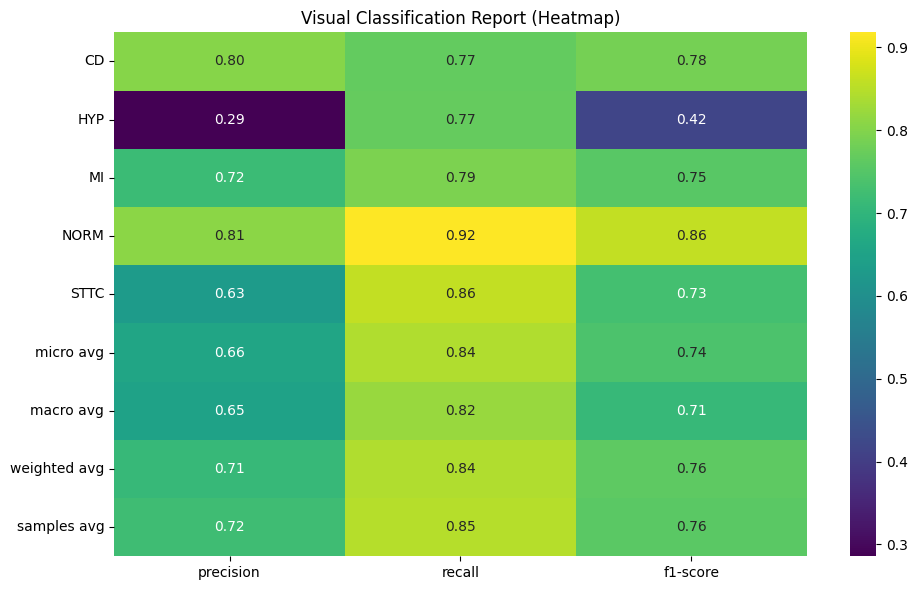

-> Visual classification report saved as 'classification_report_heatmap.png'

Generating Confusion Matrix for each class...


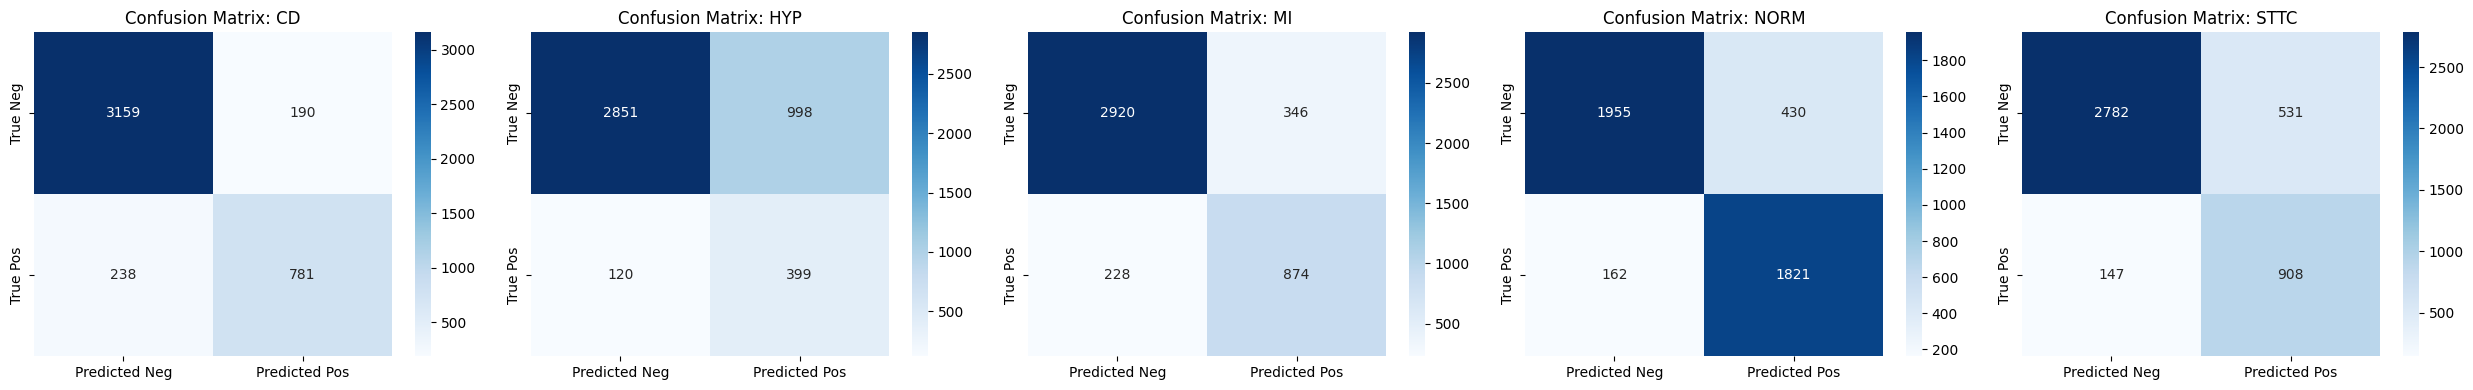

-> Multi-label confusion matrices saved to 'multilabel_confusion_matrices.png'

============================== EXPLAINABLE AI (XAI) ==============================
Generating visual explanations for sample test instances...
The bright yellow areas are what the model focused on for its diagnosis.

Displaying Saliency Map for a sample with TRUE label: 'CD' (Sample Index: 1)


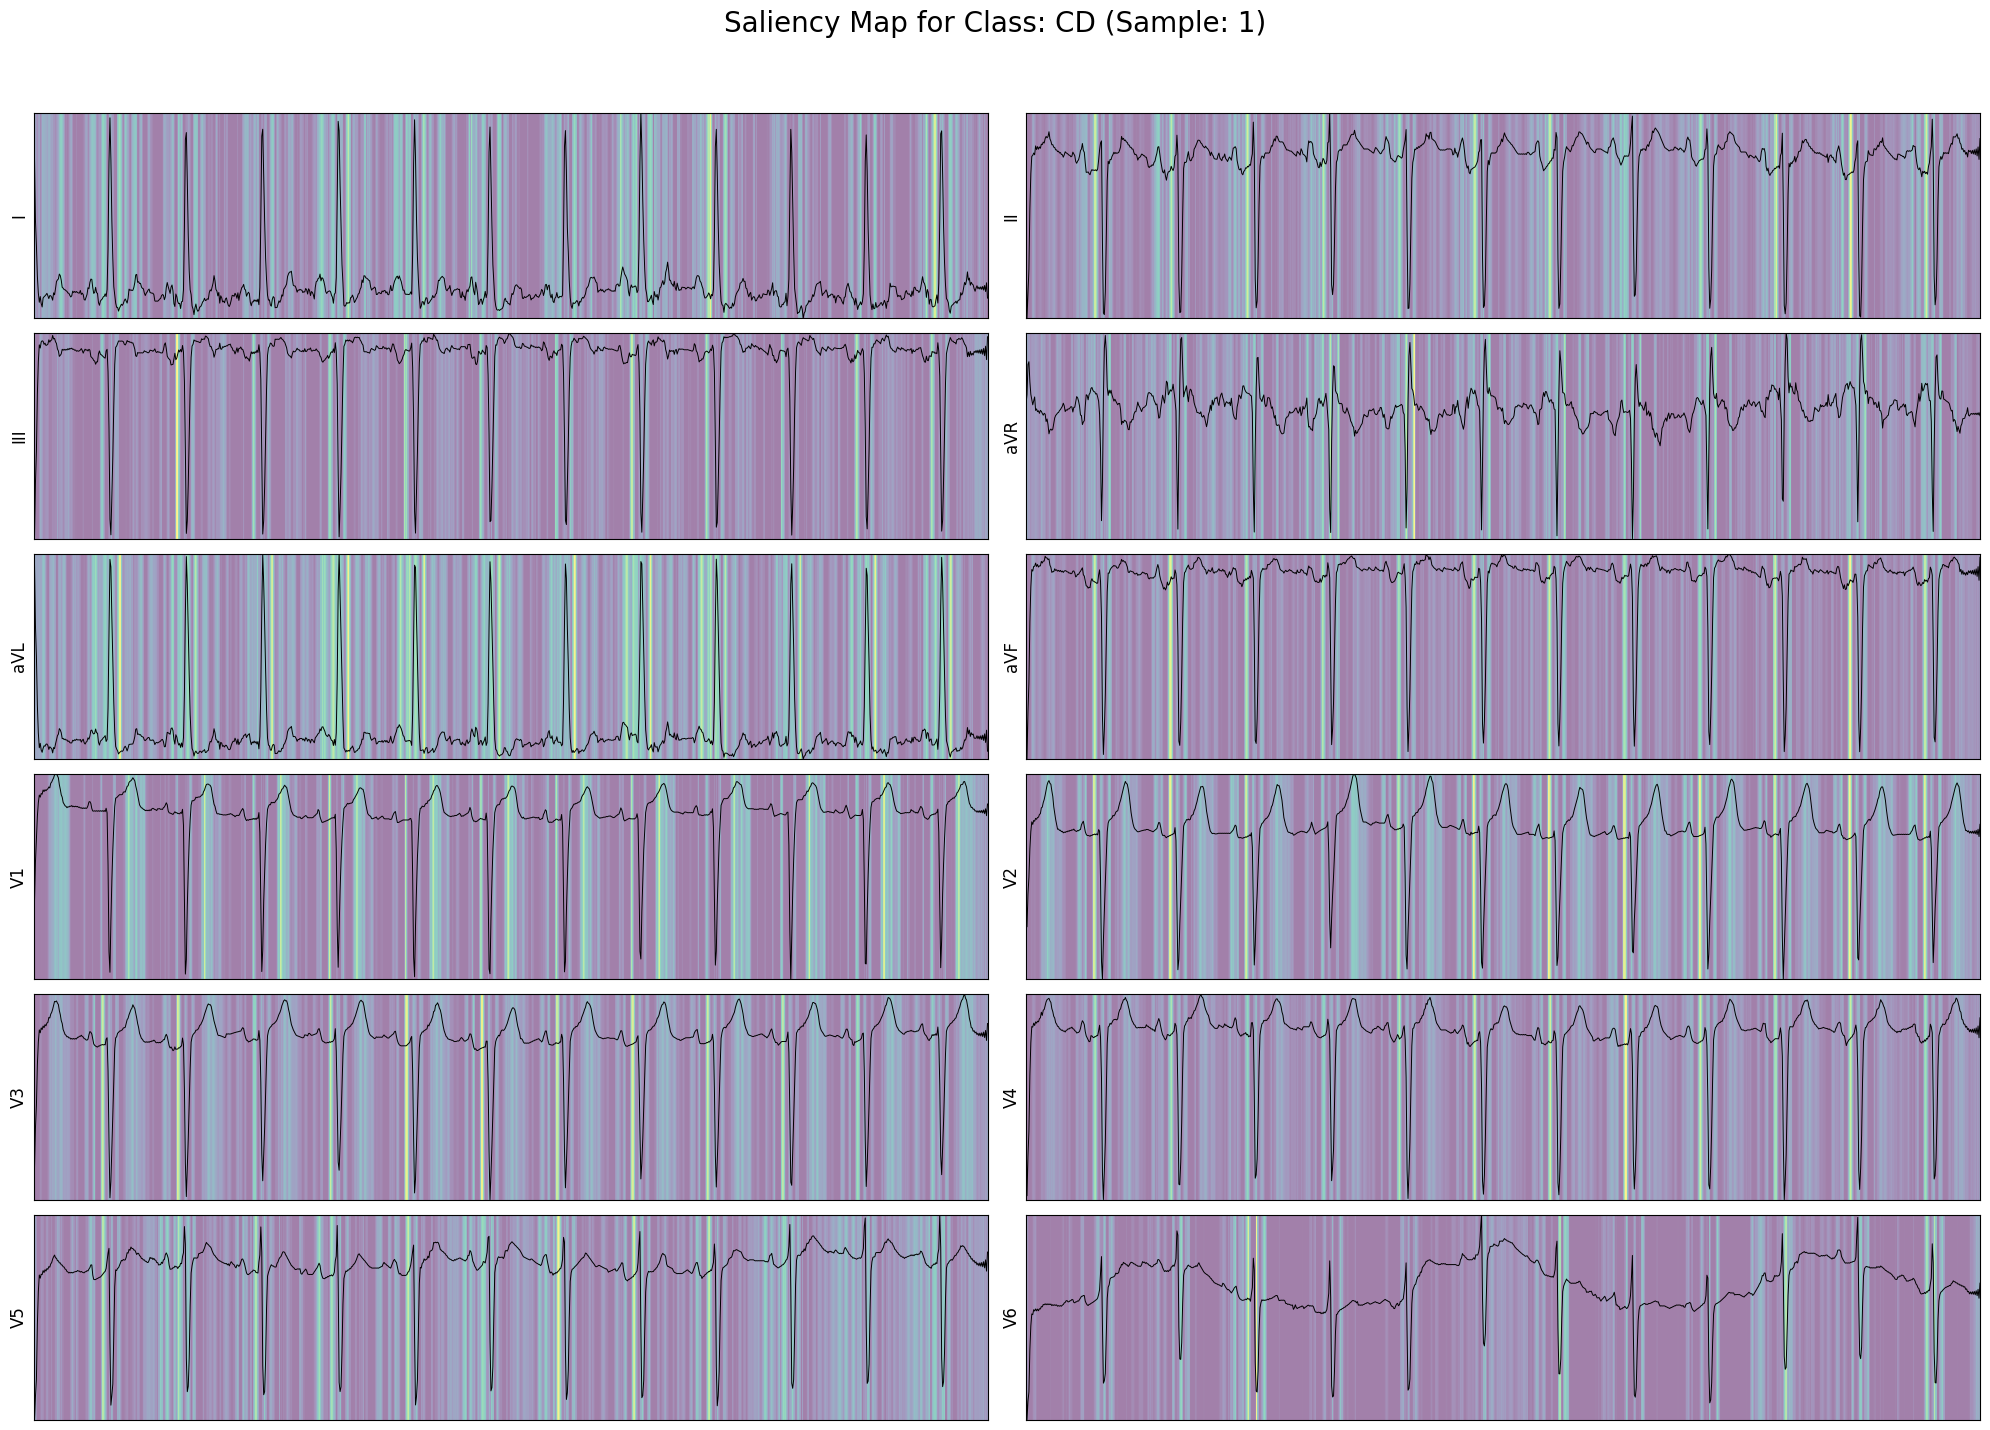


Displaying Saliency Map for a sample with TRUE label: 'HYP' (Sample Index: 13)


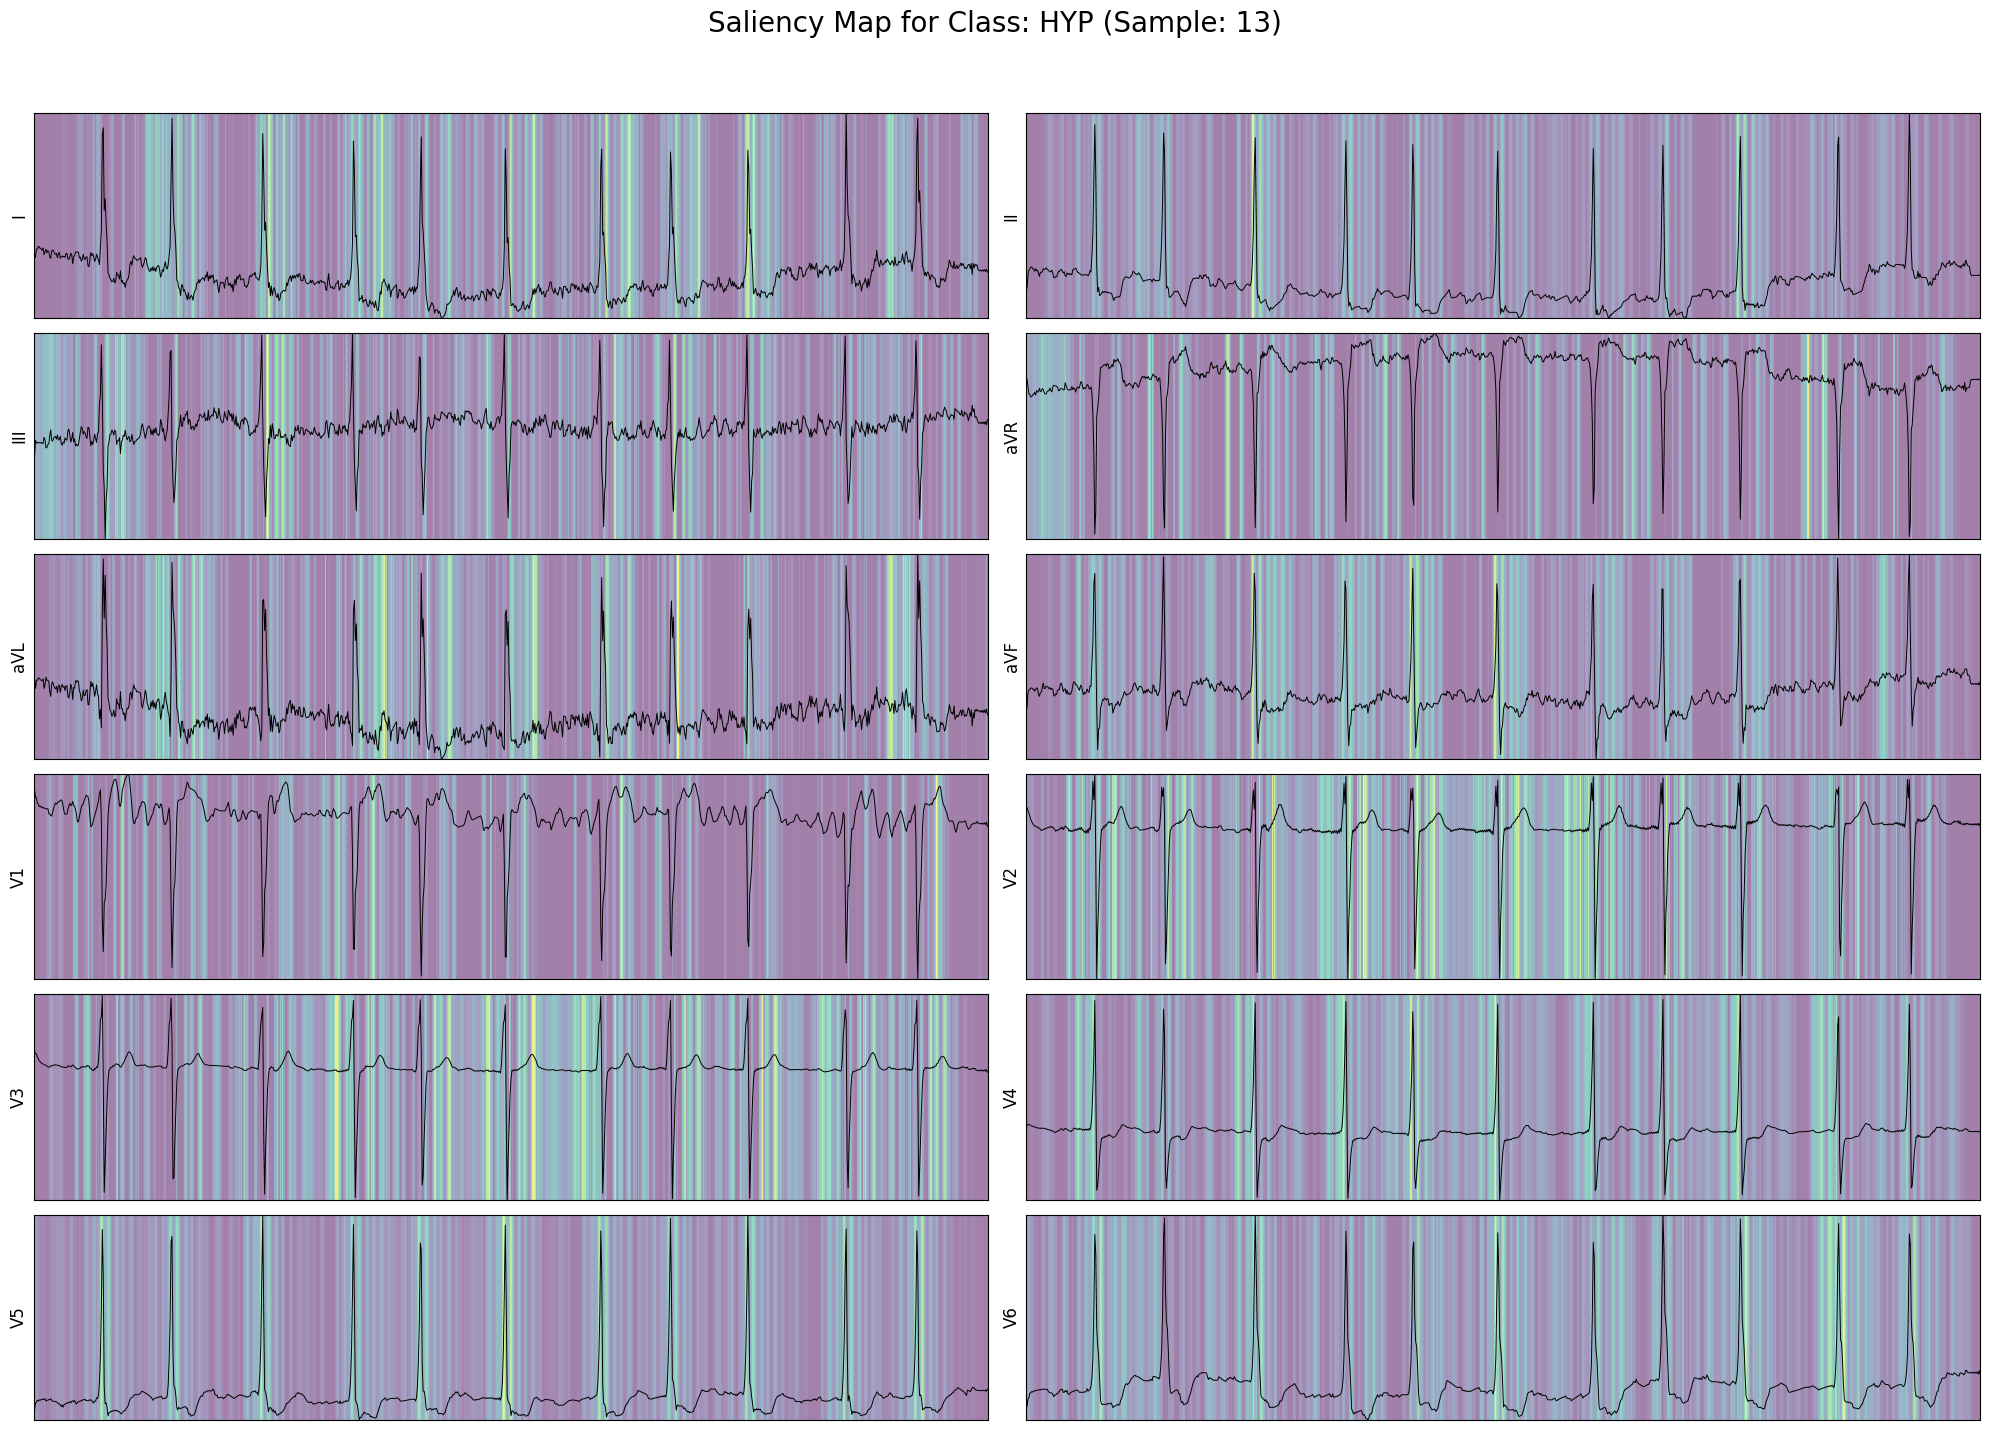


Displaying Saliency Map for a sample with TRUE label: 'MI' (Sample Index: 8)


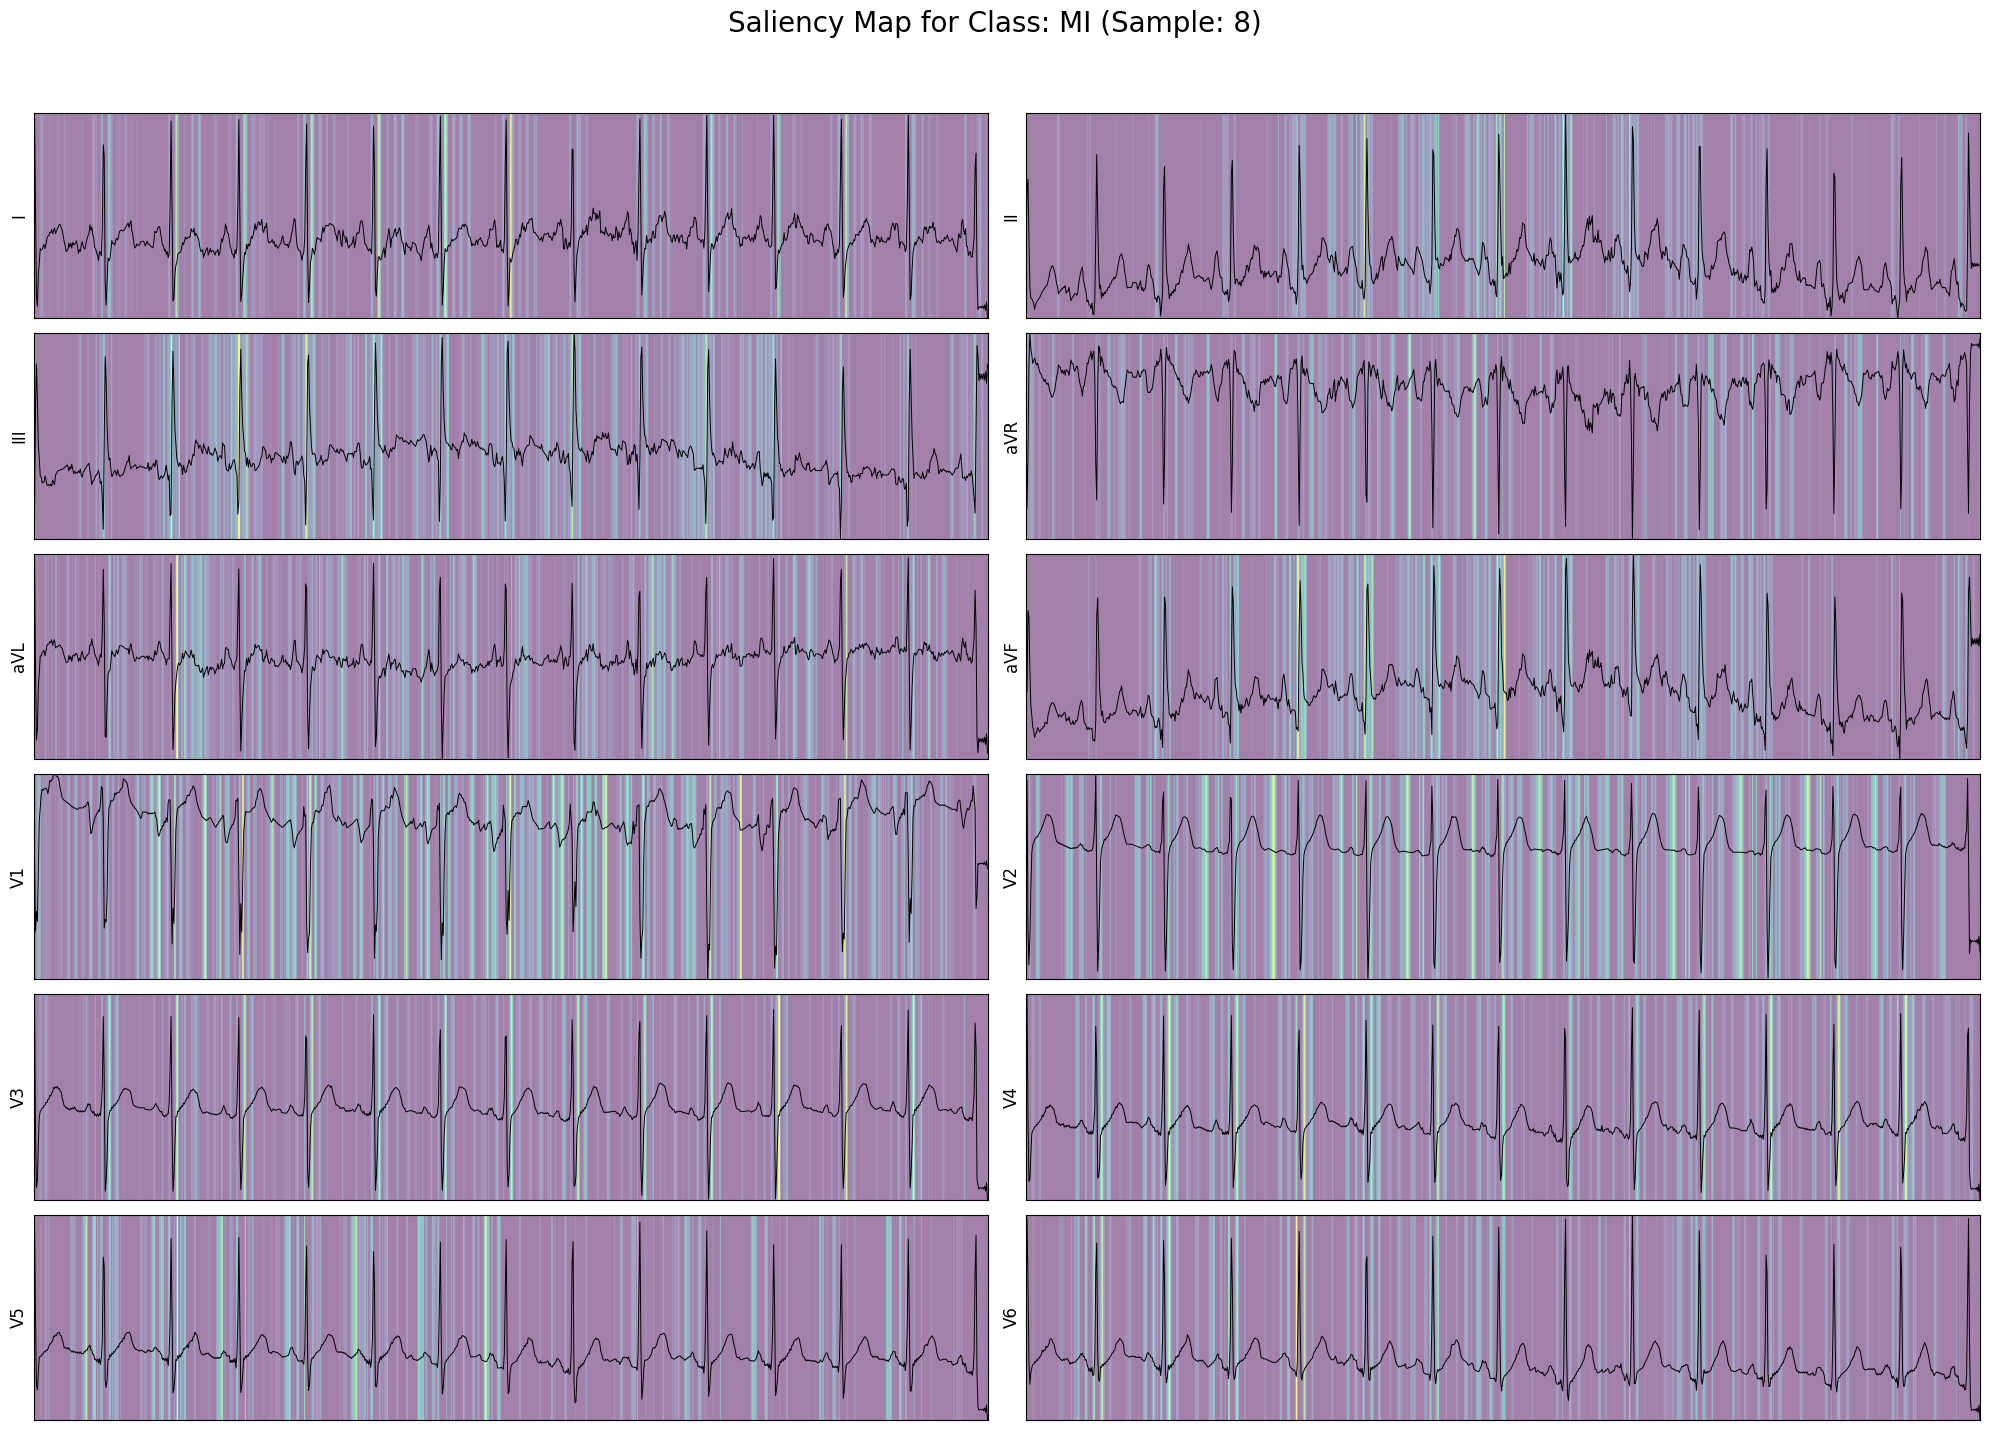


Displaying Saliency Map for a sample with TRUE label: 'NORM' (Sample Index: 0)


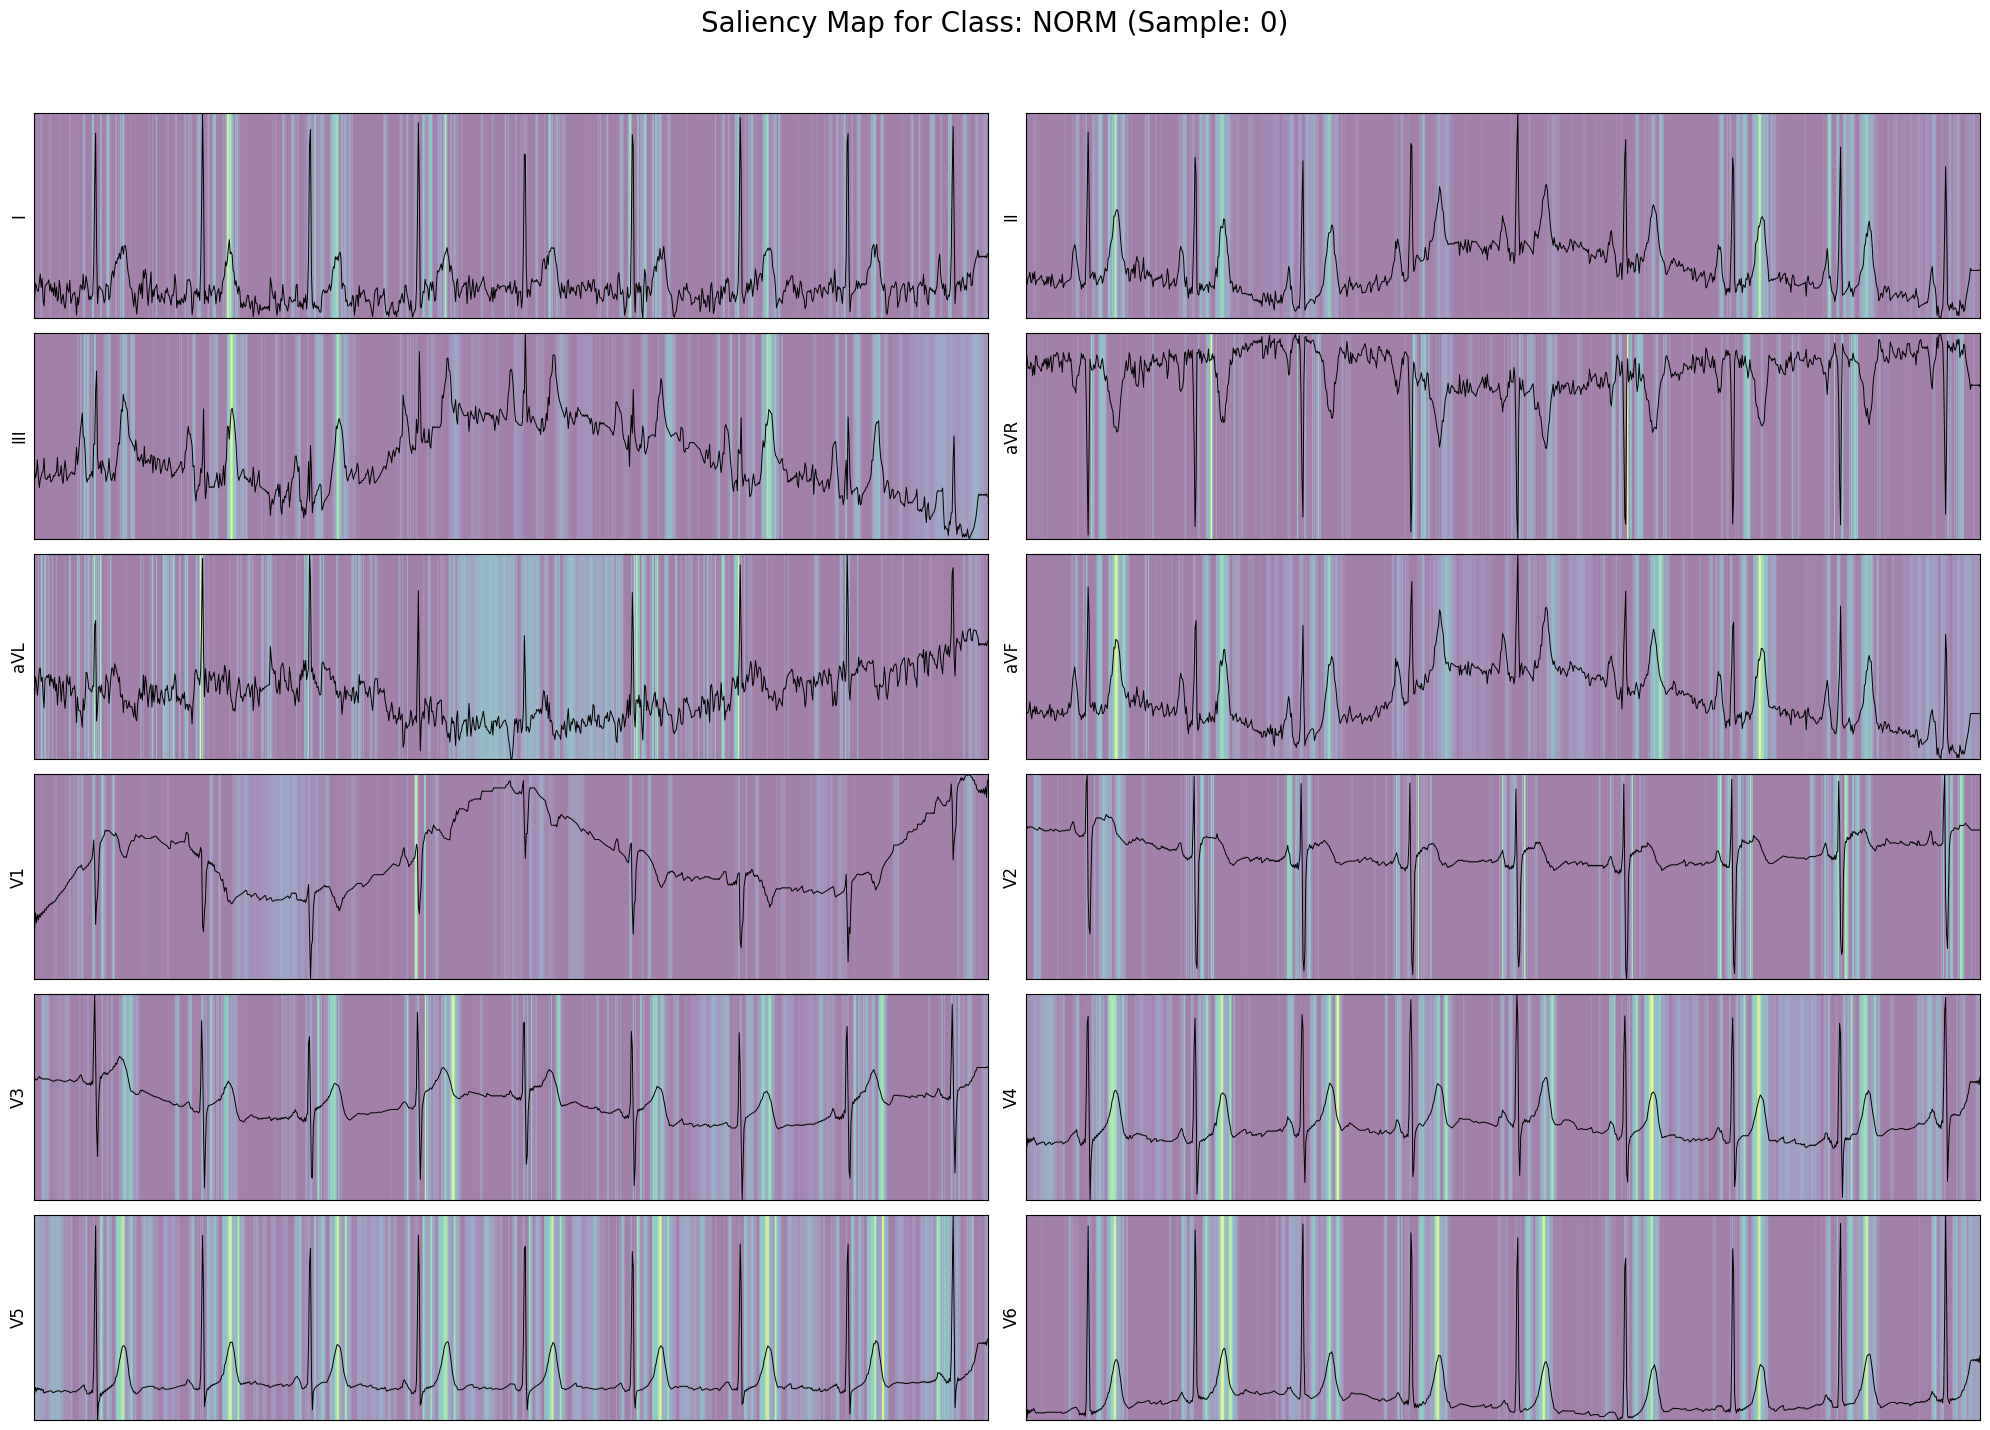


Displaying Saliency Map for a sample with TRUE label: 'STTC' (Sample Index: 4)


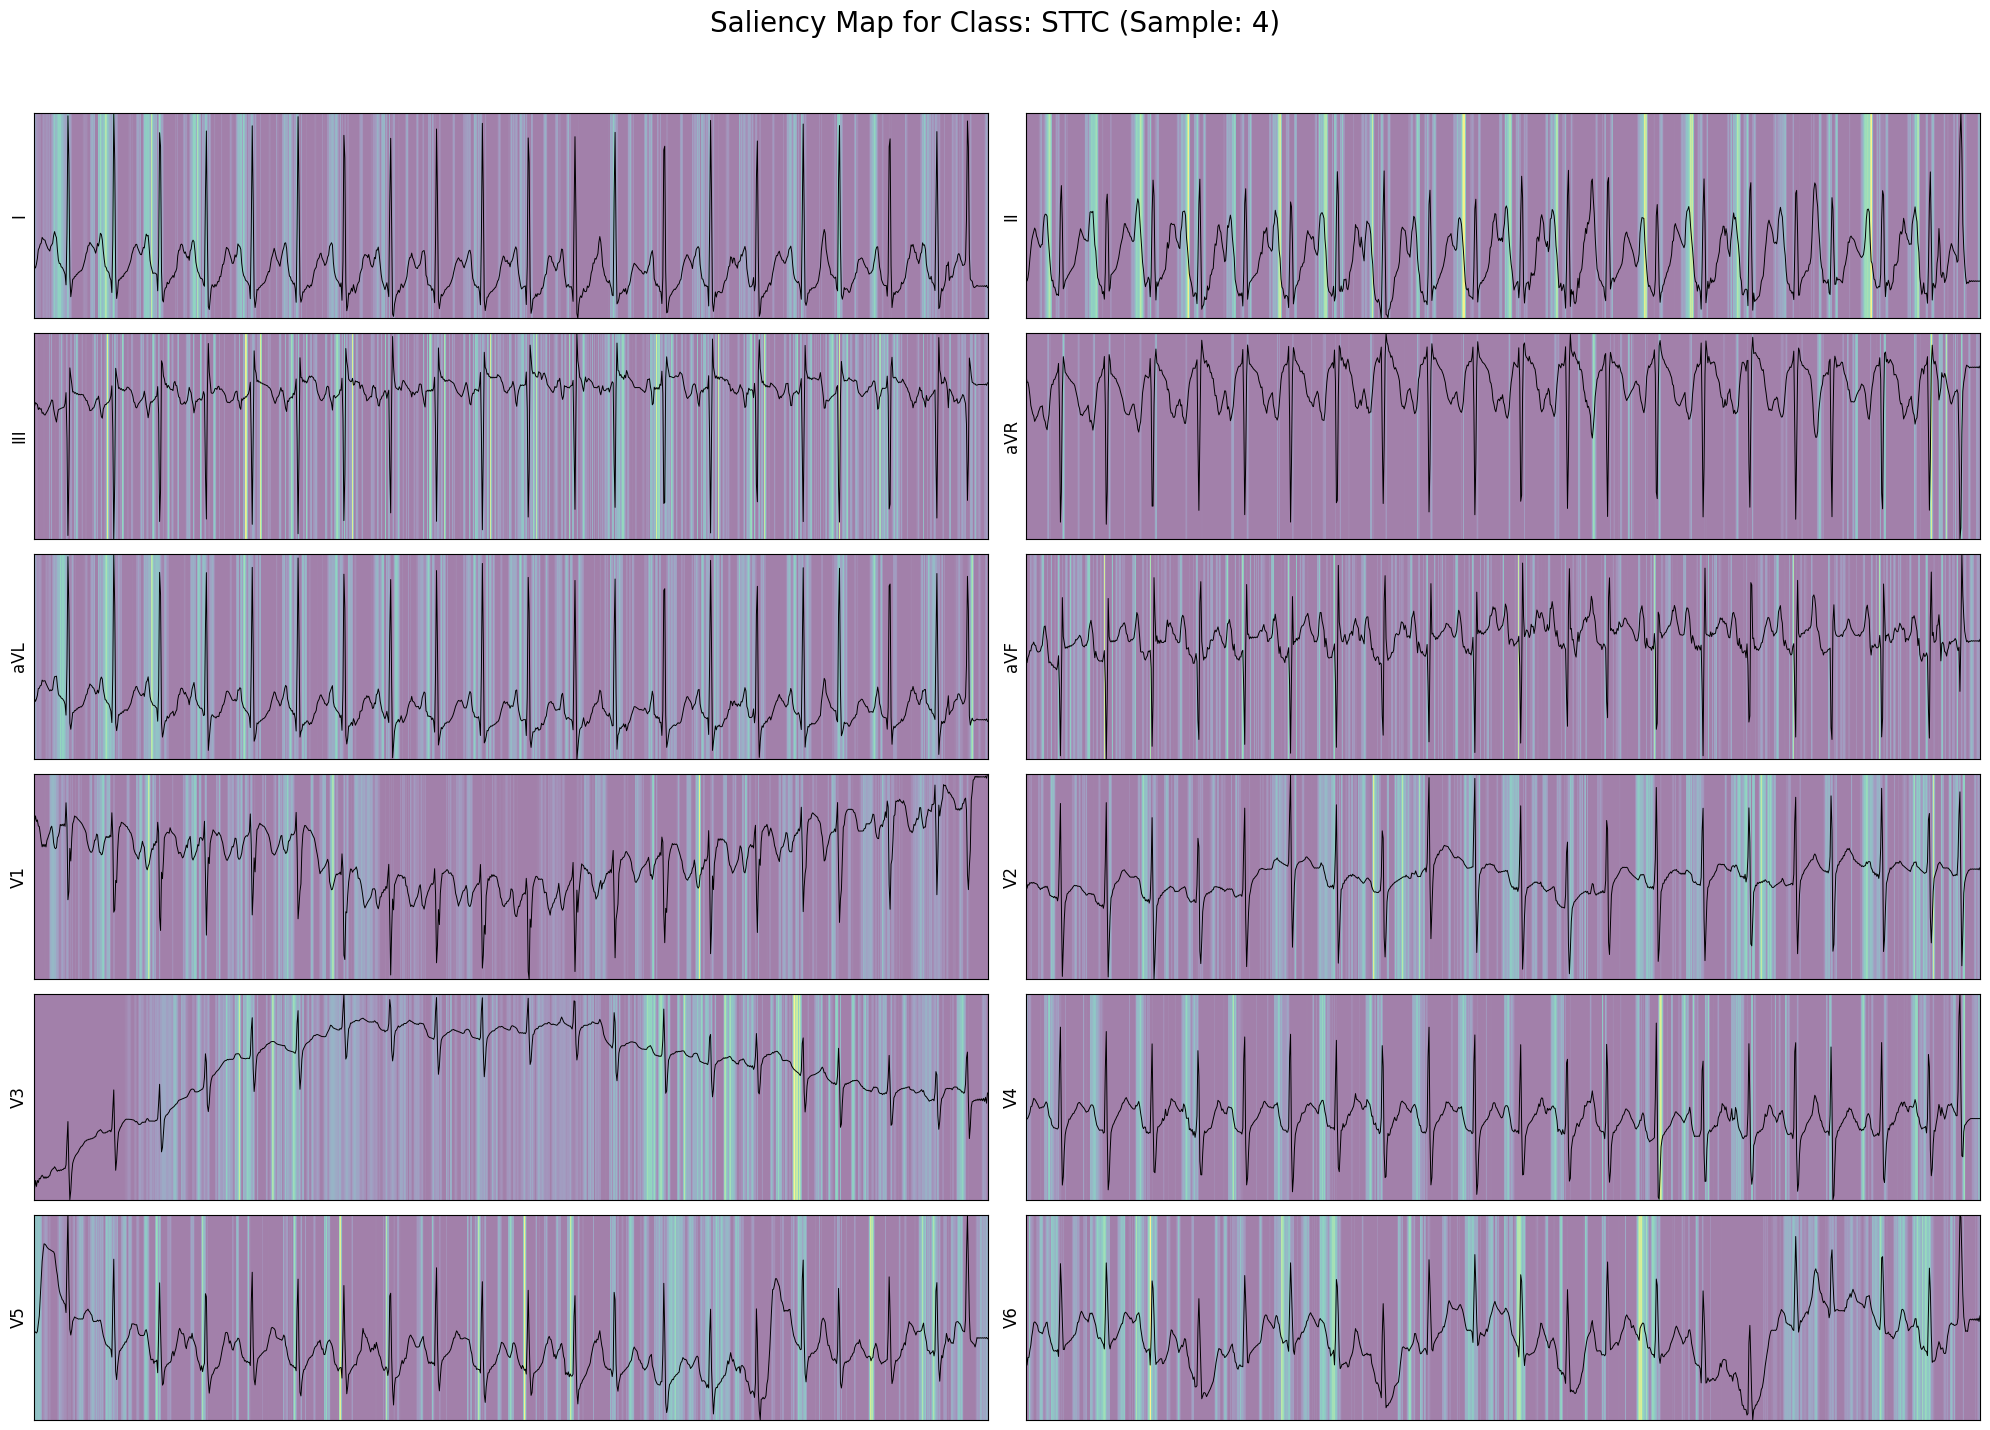


Evaluation script finished.


In [ ]:
#evaluation

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import SAGEConv, GATConv, global_mean_pool
import wfdb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, f1_score, multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample
import ast
import os
import json
import yaml
import pickle
from typing import Dict, Any, Tuple, Optional, Union
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. Configuration, Data, and Model Definitions
# =============================================================================
# NOTE: This entire section must be an EXACT copy of the corresponding section
# in the training script to ensure the model is loaded and data is processed
# in the same way.

class Config:
    """Centralized configuration class."""
    DEFAULT_CONFIG = {
        'data': {
            'ecg_folder': '/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/',
            'metadata_file': 'ptbxl_database_with_features.csv',
            'scp_file': '/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/scp_statements.csv',
            'test_size': 0.2, 'val_size': 0.1, 'random_state': 42,
            'target_sampling_rate': 100, 'signal_length': 1000
        },
        'model': {
            'cnn_out_dim': 48, 'gnn_hidden': 48, 'clinical_feature_dim': 16,
            'cnn_channels': [8, 16, 32, 64], 'dropout_rate': 0.3,
            'num_gnn_layers': 2, 'use_attention': True, 'attention_heads': 4
        },
        'training': {'batch_size': 64}
    }
    def __init__(self, config_dict: Optional[Dict] = None):
        self.config = self.DEFAULT_CONFIG.copy()
        if config_dict: self._deep_update(self.config, config_dict)
    def _deep_update(self, base: Dict, update: Dict):
        for key, value in update.items():
            if isinstance(base.get(key), dict) and isinstance(value, dict): self._deep_update(base[key], value)
            else: base[key] = value
    def get(self, key_path: str, default=None):
        keys = key_path.split('.'); current = self.config
        for key in keys:
            current = current.get(key) if isinstance(current, dict) else default
            if current is None: return default
        return current

class SignalProcessor:
    @staticmethod
    def create_anatomical_adjacency() -> torch.Tensor:
        relationships = [(0, 1), (0, 4), (1, 2), (1, 5), (2, 5), (3, 4), (3, 0), (4, 5), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), (1, 6), (5, 10), (4, 11)]
        edges = [[i, j] for i, j in relationships] + [[j, i] for i, j in relationships]
        unique_edges = list(set(tuple(sorted(e)) for e in edges))
        return torch.tensor(unique_edges, dtype=torch.long).t().contiguous()
    @staticmethod
    def normalize_signal(signal: np.ndarray) -> np.ndarray:
        std = np.std(signal)
        return (signal - np.mean(signal)) / (std + 1e-8) if std > 1e-8 else signal

class PTBXLGraphDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, config: Config):
        self.meta, self.config = meta_df, config
        self.ecg_folder = config.get('data.ecg_folder')
        self.target_sr = config.get('data.target_sampling_rate')
        self.signal_length = config.get('data.signal_length')
        self.processor = SignalProcessor()
        self.edge_index = self.processor.create_anatomical_adjacency()
    def _process_signal(self, signal: np.ndarray, original_sr: int) -> np.ndarray:
        if original_sr != self.target_sr:
            num_samples = int(signal.shape[0] * self.target_sr / original_sr)
            signal = resample(signal, num_samples)
        signal = self.processor.normalize_signal(signal)
        if len(signal) > self.signal_length: signal = signal[:self.signal_length]
        else: signal = np.pad(signal, (0, self.signal_length - len(signal)), 'constant')
        return signal
    def __len__(self): return len(self.meta)
    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        rec_path = os.path.join(self.ecg_folder, row['filename_hr']) 
        sig, meta = wfdb.rdsamp(rec_path)
        sig = sig.T
        processed_signals = np.array([self._process_signal(lead, meta['fs']) for lead in sig])
        clinical_features = row[['heart_rate', 'qrs_duration', 'qt_interval']].values.astype(np.float32)
        return Data(
            x=torch.tensor(processed_signals, dtype=torch.float32), 
            edge_index=self.edge_index, 
            y=torch.tensor(ast.literal_eval(row['encoded_labels']), dtype=torch.float),
            clinical_features=torch.tensor(clinical_features, dtype=torch.float32)
        )

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, dilation=1):
        super().__init__()
        padding = (kernel_size - 1) // 2 * dilation
        self.conv_block = nn.Sequential(nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation), nn.BatchNorm1d(out_channels), nn.LeakyReLU(0.1), nn.Dropout(0.1), nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation), nn.BatchNorm1d(out_channels))
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.activation = nn.LeakyReLU(0.1)
    def forward(self, x): return self.activation(self.conv_block(x) + self.residual(x))

class EnhancedCNN(nn.Module):
    def __init__(self, out_dim: int, channels: list, dropout_rate: float):
        super().__init__()
        self.blocks = nn.ModuleList([ResidualBlock(1 if i == 0 else channels[i-1], ch, dilation=2**i) for i, ch in enumerate(channels)])
        self.global_pools = nn.ModuleDict({'avg': nn.AdaptiveAvgPool1d(1), 'max': nn.AdaptiveMaxPool1d(1)})
        self.feature_fusion = nn.Sequential(nn.Linear(channels[-1] * 2, out_dim), nn.LeakyReLU(0.1), nn.Dropout(dropout_rate))
    def forward(self, x):
        for block in self.blocks: x = block(x)
        pooled = torch.cat([pool(x).squeeze(-1) for pool in self.global_pools.values()], dim=1)
        return self.feature_fusion(pooled)

class CNNGNNModel(nn.Module):
    def __init__(self, config: Config, num_classes: int, num_clinical_features: int):
        super().__init__()
        self.config, self.gradient_maps = config, None
        self.cnn = EnhancedCNN(config.get('model.cnn_out_dim'), config.get('model.cnn_channels'), config.get('model.dropout_rate'))
        self.gnn_layers = self._build_gnn_layers(config)
        clinical_feature_dim = config.get('model.clinical_feature_dim')
        self.clinical_mlp = nn.Sequential(nn.Linear(num_clinical_features, clinical_feature_dim), nn.BatchNorm1d(clinical_feature_dim), nn.LeakyReLU(0.1))
        gnn_hidden_dim = config.get('model.gnn_hidden')
        combined_dim = gnn_hidden_dim + clinical_feature_dim
        self.classifier = nn.Sequential(nn.Linear(combined_dim, combined_dim // 2), nn.LeakyReLU(0.1), nn.Dropout(config.get('model.dropout_rate')), nn.Linear(combined_dim // 2, num_classes))

    def _build_gnn_layers(self, config: Config):
        layers = nn.ModuleList()
        in_dim, hidden_dim = config.get('model.cnn_out_dim'), config.get('model.gnn_hidden')
        layers.append(SAGEConv(in_dim, hidden_dim))
        for _ in range(config.get('model.num_gnn_layers') - 1):
            if config.get('model.use_attention'):
                layers.append(GATConv(hidden_dim, hidden_dim, heads=config.get('model.attention_heads'), concat=False, dropout=config.get('model.dropout_rate')))
            else:
                layers.append(SAGEConv(hidden_dim, hidden_dim))
        return layers

    def activations_hook(self, grad): self.gradient_maps = grad
    
    def forward(self, data, return_cam=False):
        x, edge_index, batch, clinical_features = data.x, data.edge_index, data.batch, data.clinical_features
        x = x.unsqueeze(1)
        
        cnn_output_features = x
        for block in self.cnn.blocks: cnn_output_features = block(cnn_output_features)
        if return_cam: cnn_output_features.register_hook(self.activations_hook)
        
        pooled = torch.cat([pool(cnn_output_features).squeeze(-1) for pool in self.cnn.global_pools.values()], dim=1)
        gnn_in = self.cnn.feature_fusion(pooled)

        gnn_out = gnn_in
        for i, layer in enumerate(self.gnn_layers):
            gnn_out = layer(gnn_out, edge_index); gnn_out = F.leaky_relu(gnn_out, 0.1)
        
        gnn_out = global_mean_pool(gnn_out, batch)
        
        if clinical_features.dim() == 1:
            clinical_features = clinical_features.unsqueeze(0)
            
        clinical_out = self.clinical_mlp(clinical_features)
        combined_out = torch.cat([gnn_out, clinical_out], dim=1)
        
        return self.classifier(combined_out), cnn_output_features

# =============================================================================
# 2. Evaluation and Visualization Functions
# =============================================================================
def load_and_preprocess_data(config: Config):
    """Loads the test split of the data and the multi-label binarizer."""
    metadata_path = config.get('data.metadata_file')
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"Metadata file with features not found at '{metadata_path}'. Please run the pre-processing script first.")
    df = pd.read_csv(metadata_path)
    scp_statements = pd.read_csv(config.get('data.scp_file'), index_col=0)
    diagnostic_scp = scp_statements[scp_statements.diagnostic == 1]
    
    def get_all_diagnostic_classes(scp_dict_str):
        scp_dict = ast.literal_eval(scp_dict_str)
        classes = {diagnostic_scp.loc[c]['diagnostic_class'] for c in scp_dict.keys() if c in diagnostic_scp.index}
        return list(classes) if classes else ['NORM']

    df['diagnostic_superclass'] = df['scp_codes'].apply(get_all_diagnostic_classes)
    
    # Load the fitted label encoder from training
    encoder_path = 'label_encoder.pkl'
    if not os.path.exists(encoder_path):
        raise FileNotFoundError(f"Label encoder not found at '{encoder_path}'. Please run the training script first.")
    with open(encoder_path, 'rb') as f:
        mlb = pickle.load(f)
        
    encoded_labels = mlb.transform(df['diagnostic_superclass'])
    df['encoded_labels'] = [str(list(e)) for e in encoded_labels]
    
    _, test_df = train_test_split(df, test_size=config.get('data.test_size'), random_state=config.get('data.random_state'))
    return test_df.reset_index(drop=True), mlb

def generate_saliency_map(model, data, target_class_idx, device):
    """Generates a Grad-CAM saliency map for a given sample and target class."""
    model.eval(); data = data.to(device); data.x.requires_grad = True
    predictions, feature_maps = model(data, return_cam=True)
    score = predictions[0][target_class_idx]
    model.zero_grad(); score.backward()
    gradients = model.gradient_maps.detach()
    pooled_gradients = torch.mean(gradients, dim=[2], keepdim=True)
    feature_maps = feature_maps.detach()
    for i in range(feature_maps.shape[1]): feature_maps[:, i, :] *= pooled_gradients[:, i, :]
    heatmap = torch.mean(feature_maps, dim=1).squeeze()
    heatmap = F.relu(heatmap); heatmap /= torch.max(heatmap)
    return heatmap.cpu().numpy()

def plot_saliency(data, heatmap, class_name, sample_idx):
    """Plots the 12-lead ECG with the saliency map overlaid."""
    leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    fig, axs = plt.subplots(6, 2, figsize=(20, 15))
    fig.suptitle(f'Saliency Map for Class: {class_name} (Sample: {sample_idx})', fontsize=20)
    for i, ax in enumerate(axs.flat):
        signal = data.x[i].detach().cpu().numpy(); time = np.arange(len(signal))
        ax.plot(time, signal, color='black', linewidth=0.7)
        ax.imshow(heatmap[i][np.newaxis, :], cmap='viridis', aspect="auto", extent=[time[0], time[-1], np.min(signal), np.max(signal)], alpha=0.5)
        ax.set_ylabel(leads[i], fontsize=12); ax.set_yticks([]); ax.set_xticks([])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()
    fig.savefig(f'saliency_{class_name}_{sample_idx}.png'); plt.close(fig)

def custom_collate(data_list):
    """Custom collate function to correctly batch graph data and custom attributes."""
    batch = Batch.from_data_list([Data(x=d.x, edge_index=d.edge_index) for d in data_list])
    y = torch.stack([d.y for d in data_list], dim=0)
    clinical_features = torch.stack([d.clinical_features for d in data_list], dim=0)
    batch.y = y
    batch.clinical_features = clinical_features
    return batch

# =============================================================================
# 3. Main Evaluation Block
# =============================================================================
def evaluate_model(model_path='best_model.pth'):
    """Loads a trained model and runs a full evaluation on the test set."""
    if not os.path.exists(model_path):
        print(f"Error: Model file not found at '{model_path}'"); return

    # --- 1. Setup ---
    config = Config(); device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # --- 2. Load Data and Label Encoder ---
    print("Loading and preprocessing test data...")
    test_df, label_encoder = load_and_preprocess_data(config)
    test_dataset = PTBXLGraphDataset(test_df, config)
    test_loader = DataLoader(test_dataset, batch_size=config.get('training.batch_size'), shuffle=False, collate_fn=custom_collate)
    print(f"Test dataset loaded with {len(test_dataset)} samples.")

    # --- 3. Initialize and Load Model ---
    print(f"Loading model from '{model_path}'...")
    num_classes = len(label_encoder.classes_)
    model = CNNGNNModel(config, num_classes, num_clinical_features=3).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device)); model.eval()

    # --- 4. Get Predictions ---
    print("Running evaluation on the test set...")
    all_preds, all_targets = [], []
    with torch.no_grad():
        for data in tqdm(test_loader, desc="Evaluating"):
            data = data.to(device)
            out, _ = model(data)
            preds = (torch.sigmoid(out) > 0.5).cpu().numpy()
            all_preds.append(preds); all_targets.append(data.y.cpu().numpy())
    all_preds, all_targets = np.concatenate(all_preds), np.concatenate(all_targets)

    # --- 5. Display Performance Reports ---
    print("\n" + "="*30 + " EVALUATION RESULTS " + "="*30)
    f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    print(f"Final Test F1-Score (Weighted): {f1:.4f}\n")
    
    print("\nGenerating visual classification report...")
    report_dict = classification_report(all_targets, all_preds, target_names=label_encoder.classes_, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).iloc[:-1, :].T
    fig, ax = plt.subplots(figsize=(10, max(6, len(label_encoder.classes_) * 0.5)))
    sns.heatmap(report_df[['precision', 'recall', 'f1-score']], annot=True, cmap='viridis', fmt='.2f', ax=ax)
    ax.set_title('Visual Classification Report (Heatmap)'); plt.tight_layout(); plt.show()
    fig.savefig('classification_report_heatmap.png'); plt.close(fig)
    print("-> Visual classification report saved as 'classification_report_heatmap.png'")

    print("\nGenerating Confusion Matrix for each class...")
    mcm = multilabel_confusion_matrix(all_targets, all_preds)
    fig, axes = plt.subplots(1, len(label_encoder.classes_), figsize=(5 * len(label_encoder.classes_), 4))
    for i, (matrix, label) in enumerate(zip(mcm, label_encoder.classes_)):
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=['Predicted Neg', 'Predicted Pos'],
                    yticklabels=['True Neg', 'True Pos'])
        axes[i].set_title(f'Confusion Matrix: {label}')
    plt.tight_layout(); plt.show()
    fig.savefig('multilabel_confusion_matrices.png'); plt.close(fig)
    print("-> Multi-label confusion matrices saved to 'multilabel_confusion_matrices.png'")

    # --- 6. Generate Saliency Maps (XAI) ---
    print("\n" + "="*30 + " EXPLAINABLE AI (XAI) " + "="*30)
    print("Generating visual explanations for sample test instances...")
    print("The bright yellow areas are what the model focused on for its diagnosis.")
    for class_idx, class_name in enumerate(label_encoder.classes_):
        sample_found = False
        for i in range(len(test_dataset)):
            if ast.literal_eval(test_dataset.meta.iloc[i]['encoded_labels'])[class_idx] == 1:
                sample_data = test_dataset[i]
                print(f"\nDisplaying Saliency Map for a sample with TRUE label: '{class_name}' (Sample Index: {i})")
                heatmap = generate_saliency_map(model, sample_data, class_idx, device)
                plot_saliency(sample_data, heatmap, class_name, i)
                sample_found = True; break
        if not sample_found:
            print(f"  - No positive samples found for class '{class_name}' in the first {len(test_dataset)} test items.")
            
    print("\nEvaluation script finished.")

if __name__ == "__main__":
    evaluate_model()


In [4]:
#hyperparameter tuning

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import SAGEConv, GATConv, global_mean_pool
import wfdb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score
import ast
import os
import yaml
import pickle
import optuna
from typing import Dict, Any, Optional
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. Configuration, Data, and Model Definitions (Copied from Training Script)
# =============================================================================
class Config:
    """Centralized configuration class, to be modified by Optuna trials."""
    DEFAULT_CONFIG = {
        'data': {
            'ecg_folder': '/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/',
            'metadata_file': 'ptbxl_database_with_features.csv',
            'scp_file': '/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/scp_statements.csv',
            'test_size': 0.2, 'val_size': 0.1, 'random_state': 42,
            'target_sampling_rate': 100, 'signal_length': 1000
        },
        'model': {
            'cnn_out_dim': 48, 'gnn_hidden': 48, 'clinical_feature_dim': 16,
            'cnn_channels': [8, 16, 32, 64], 'dropout_rate': 0.3,
            'num_gnn_layers': 2, 'use_attention': True, 'attention_heads': 4
        },
        'training': {
            'batch_size': 64, 'learning_rate': 0.0005, 'weight_decay': 0.01,
            'epochs': 15, # Shortened for tuning
            'gradient_clip': 1.0, 'scheduler_patience': 5, 'scheduler_factor': 0.5, 
            'mixed_precision': True, 'early_stopping_patience': 7
        },
        'augmentation': {
            'lead_dropout_prob': 0.1, 'noise_std': 0.02,
            'amplitude_scale_range': [0.9, 1.1], 'time_shift_range': [-50, 50],
            'enable_augmentation': True
        }
    }
    def __init__(self, config_dict: Optional[Dict] = None):
        self.config = self.DEFAULT_CONFIG.copy()
        if config_dict: self._deep_update(self.config, config_dict)
    def _deep_update(self, base: Dict, update: Dict):
        for key, value in update.items():
            if isinstance(base.get(key), dict) and isinstance(value, dict): self._deep_update(base[key], value)
            else: base[key] = value
    def get(self, key_path: str, default=None):
        keys = key_path.split('.'); current = self.config
        for key in keys:
            current = current.get(key) if isinstance(current, dict) else default
            if current is None: return default
        return current

class SignalProcessor:
    @staticmethod
    def create_anatomical_adjacency() -> torch.Tensor:
        relationships = [(0, 1), (0, 4), (1, 2), (1, 5), (2, 5), (3, 4), (3, 0), (4, 5), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11), (1, 6), (5, 10), (4, 11)]
        edges = [[i, j] for i, j in relationships] + [[j, i] for i, j in relationships]
        unique_edges = list(set(tuple(sorted(e)) for e in edges))
        return torch.tensor(unique_edges, dtype=torch.long).t().contiguous()
    @staticmethod
    def normalize_signal(signal: np.ndarray) -> np.ndarray:
        std = np.std(signal); return (signal - np.mean(signal)) / (std + 1e-8) if std > 1e-8 else signal

class PTBXLGraphDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, config: Config):
        self.meta, self.config = meta_df, config
        self.ecg_folder = config.get('data.ecg_folder')
        self.target_sr = config.get('data.target_sampling_rate')
        self.signal_length = config.get('data.signal_length')
        self.processor = SignalProcessor()
        self.edge_index = self.processor.create_anatomical_adjacency()
    def _process_signal(self, signal: np.ndarray, original_sr: int) -> np.ndarray:
        if original_sr != self.target_sr:
            num_samples = int(signal.shape[0] * self.target_sr / original_sr)
            signal = resample(signal, num_samples)
        signal = self.processor.normalize_signal(signal)
        if len(signal) > self.signal_length: signal = signal[:self.signal_length]
        else: signal = np.pad(signal, (0, self.signal_length - len(signal)), 'constant')
        return signal
    def __len__(self): return len(self.meta)
    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        rec_path = os.path.join(self.ecg_folder, row['filename_hr']) 
        sig, meta = wfdb.rdsamp(rec_path)
        sig = sig.T
        processed_signals = np.array([self._process_signal(lead, meta['fs']) for lead in sig])
        clinical_features = row[['heart_rate', 'qrs_duration', 'qt_interval']].values.astype(np.float32)
        return Data(
            x=torch.tensor(processed_signals, dtype=torch.float32), 
            edge_index=self.edge_index, 
            y=torch.tensor(ast.literal_eval(row['encoded_labels']), dtype=torch.float),
            clinical_features=torch.tensor(clinical_features, dtype=torch.float32)
        )

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, dilation=1):
        super().__init__()
        padding = (kernel_size - 1) // 2 * dilation
        self.conv_block = nn.Sequential(nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation), nn.BatchNorm1d(out_channels), nn.LeakyReLU(0.1), nn.Dropout(0.1), nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation), nn.BatchNorm1d(out_channels))
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.activation = nn.LeakyReLU(0.1)
    def forward(self, x): return self.activation(self.conv_block(x) + self.residual(x))

class EnhancedCNN(nn.Module):
    def __init__(self, out_dim: int, channels: list, dropout_rate: float):
        super().__init__()
        self.blocks = nn.ModuleList([ResidualBlock(1 if i == 0 else channels[i-1], ch, dilation=2**i) for i, ch in enumerate(channels)])
        self.global_pools = nn.ModuleDict({'avg': nn.AdaptiveAvgPool1d(1), 'max': nn.AdaptiveMaxPool1d(1)})
        self.feature_fusion = nn.Sequential(nn.Linear(channels[-1] * 2, out_dim), nn.LeakyReLU(0.1), nn.Dropout(dropout_rate))
    def forward(self, x):
        for block in self.blocks: x = block(x)
        pooled = torch.cat([pool(x).squeeze(-1) for pool in self.global_pools.values()], dim=1)
        return self.feature_fusion(pooled)

class CNNGNNModel(nn.Module):
    def __init__(self, config: Config, num_classes: int, num_clinical_features: int):
        super().__init__()
        self.config = config
        self.cnn = EnhancedCNN(config.get('model.cnn_out_dim'), config.get('model.cnn_channels'), config.get('model.dropout_rate'))
        self.gnn_layers = self._build_gnn_layers(config)
        clinical_feature_dim = config.get('model.clinical_feature_dim')
        self.clinical_mlp = nn.Sequential(nn.Linear(num_clinical_features, clinical_feature_dim), nn.BatchNorm1d(clinical_feature_dim), nn.LeakyReLU(0.1))
        gnn_hidden_dim = config.get('model.gnn_hidden')
        combined_dim = gnn_hidden_dim + clinical_feature_dim
        self.classifier = nn.Sequential(nn.Linear(combined_dim, combined_dim // 2), nn.LeakyReLU(0.1), nn.Dropout(config.get('model.dropout_rate')), nn.Linear(combined_dim // 2, num_classes))
        self.apply(self._init_weights)
    def _build_gnn_layers(self, config: Config):
        layers = nn.ModuleList()
        in_dim, hidden_dim = config.get('model.cnn_out_dim'), config.get('model.gnn_hidden')
        layers.append(SAGEConv(in_dim, hidden_dim))
        for _ in range(config.get('model.num_gnn_layers') - 1):
            if config.get('model.use_attention'):
                layers.append(GATConv(hidden_dim, hidden_dim, heads=config.get('model.attention_heads'), concat=False, dropout=config.get('model.dropout_rate')))
            else:
                layers.append(SAGEConv(hidden_dim, hidden_dim))
        return layers
    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Conv1d)):
            nn.init.xavier_uniform_(module.weight, gain=0.8)
            if module.bias is not None: nn.init.constant_(module.bias, 0)
    def forward(self, data):
        x, edge_index, batch, clinical_features = data.x, data.edge_index, data.batch, data.clinical_features
        x = x.unsqueeze(1); x = self.cnn(x)
        for i, layer in enumerate(self.gnn_layers):
            x = layer(x, edge_index); x = F.leaky_relu(x, 0.1)
            if i < len(self.gnn_layers) - 1: x = F.dropout(x, p=self.config.get('model.dropout_rate'), training=self.training)
        gnn_out = global_mean_pool(x, batch)
        clinical_out = self.clinical_mlp(clinical_features)
        combined_out = torch.cat([gnn_out, clinical_out], dim=1)
        return self.classifier(combined_out)

class Trainer:
    def __init__(self, model: nn.Module, config: Config, device: torch.device, pos_weight=None):
        self.model, self.config, self.device = model, config, device
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=config.get('training.learning_rate'), weight_decay=config.get('training.weight_decay'))
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.scaler = torch.cuda.amp.GradScaler() if config.get('training.mixed_precision') else None
    def _run_epoch(self, loader: DataLoader, is_training: bool = True):
        self.model.train(is_training)
        total_loss = 0; all_preds, all_targets = [], []
        for data in loader:
            data = data.to(self.device)
            with torch.set_grad_enabled(is_training):
                with torch.cuda.amp.autocast(enabled=self.scaler is not None):
                    out = self.model(data); loss = self.criterion(out, data.y)
                if is_training:
                    self.optimizer.zero_grad()
                    if self.scaler:
                        self.scaler.scale(loss).backward(); self.scaler.unscale_(self.optimizer)
                        torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.get('training.gradient_clip'))
                        self.scaler.step(self.optimizer); self.scaler.update()
                    else:
                        loss.backward(); torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.get('training.gradient_clip')); self.optimizer.step()
            total_loss += loss.item() * data.y.size(0)
            preds = (torch.sigmoid(out) > 0.5).cpu().numpy()
            all_preds.append(preds); all_targets.append(data.y.cpu().numpy())
        all_preds, all_targets = np.concatenate(all_preds), np.concatenate(all_targets)
        return f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    def train(self, train_loader, val_loader):
        best_val_f1 = 0.0
        for epoch in range(1, self.config.get('training.epochs') + 1):
            _ = self._run_epoch(train_loader, is_training=True)
            val_f1 = self._run_epoch(val_loader, is_training=False)
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
        return best_val_f1

def load_and_preprocess_data(config: Config):
    metadata_path = config.get('data.metadata_file')
    df = pd.read_csv(metadata_path)
    scp_statements = pd.read_csv(config.get('data.scp_file'), index_col=0)
    diagnostic_scp = scp_statements[scp_statements.diagnostic == 1]
    def get_all_diagnostic_classes(scp_dict_str):
        scp_dict = ast.literal_eval(scp_dict_str)
        classes = {diagnostic_scp.loc[c]['diagnostic_class'] for c in scp_dict.keys() if c in diagnostic_scp.index}
        return list(classes) if classes else ['NORM']
    df['diagnostic_superclass'] = df['scp_codes'].apply(get_all_diagnostic_classes)
    mlb = MultiLabelBinarizer()
    encoded_labels = mlb.fit_transform(df['diagnostic_superclass'])
    df['encoded_labels'] = [str(list(e)) for e in encoded_labels]
    train_df, _ = train_test_split(df, test_size=config.get('data.test_size'), random_state=config.get('data.random_state'))
    train_df, val_df = train_test_split(train_df, test_size=config.get('data.val_size') / (1 - config.get('data.test_size')), random_state=config.get('data.random_state'))
    return {'train': train_df.reset_index(drop=True), 'val': val_df.reset_index(drop=True), 'label_encoder': mlb, 'num_classes': len(mlb.classes_)}

def custom_collate(data_list):
    batch = Batch.from_data_list([Data(x=d.x, edge_index=d.edge_index) for d in data_list])
    y = torch.stack([d.y for d in data_list], dim=0)
    clinical_features = torch.stack([d.clinical_features for d in data_list], dim=0)
    batch.y = y; batch.clinical_features = clinical_features
    return batch

# =============================================================================
# 2. Optuna Objective Function
# =============================================================================
def objective(trial: optuna.trial.Trial, data_info: Dict, device: torch.device) -> float:
    """
    The main objective function for Optuna to optimize.
    A 'trial' represents one set of hyperparameters.
    """
    # --- 1. Suggest Hyperparameters ---
    trial_params = {
        'training.learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
        'training.weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
        'model.dropout_rate': trial.suggest_float('dropout_rate', 0.1, 0.5),
        'model.attention_heads': trial.suggest_categorical('attention_heads', [2, 4, 8]),
    }
    config = Config(config_dict=trial_params)

    # --- 2. Setup Datasets and Model for this trial ---
    datasets = {split: PTBXLGraphDataset(data_info[split], config) for split in ['train', 'val']}
    train_labels = np.array([ast.literal_eval(i) for i in data_info['train']['encoded_labels']])
    pos_counts = train_labels.sum(axis=0); neg_counts = len(train_labels) - pos_counts
    pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float).to(device)
    
    train_loader = DataLoader(datasets['train'], shuffle=True, batch_size=config.get('training.batch_size'), num_workers=2, pin_memory=True, collate_fn=custom_collate)
    val_loader = DataLoader(datasets['val'], batch_size=config.get('training.batch_size'), shuffle=False, num_workers=2, pin_memory=True, collate_fn=custom_collate)

    model = CNNGNNModel(config, data_info['num_classes'], num_clinical_features=3).to(device)
    trainer = Trainer(model, config, device, pos_weight=pos_weight)

    # --- 3. Run a shortened training and return the best validation F1 ---
    print(f"\n--- Starting Trial {trial.number} ---")
    best_val_f1 = trainer.train(train_loader, val_loader)
    
    return best_val_f1

# =============================================================================
# 3. Main Execution Block
# =============================================================================
def main():
    # --- 1. Initial Setup (Load data once) ---
    config = Config()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    data_info = load_and_preprocess_data(config)
    print(f"Classes found ({data_info['num_classes']}): {list(data_info['label_encoder'].classes_)}")

    # --- 2. Run Optuna Study ---
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, data_info, device), n_trials=20) # n_trials can be increased for a more thorough search

    # --- 3. Print Best Results ---
    print("\n" + "="*30 + " HYPERPARAMETER TUNING COMPLETE " + "="*30)
    print(f"Number of finished trials: {len(study.trials)}")
    print("Best trial:")
    trial = study.best_trial

    print(f"  Value (Validation F1): {trial.value:.4f}")
    print("  Params: ")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")
        
    print("\n-> Please update these best parameters in your main training script's Config class.")

if __name__ == "__main__":
    main()

Using device: cuda


[I 2025-07-25 09:49:54,897] A new study created in memory with name: no-name-9b36e100-3c76-4090-9def-fff1a5f06d2e


Classes found (5): ['CD', 'HYP', 'MI', 'NORM', 'STTC']

--- Starting Trial 0 ---


[I 2025-07-25 10:09:30,148] Trial 0 finished with value: 0.7437049838041352 and parameters: {'learning_rate': 0.00010282244568298578, 'weight_decay': 0.0002932284843487223, 'dropout_rate': 0.3025518663431923, 'attention_heads': 8}. Best is trial 0 with value: 0.7437049838041352.



--- Starting Trial 1 ---


...


--- Starting Trial 18 ---


[I 2025-07-25 15:57:48,591] Trial 18 finished with value: 0.7451068761583302 and parameters: {'learning_rate': 0.0009746869873978411, 'weight_decay': 0.001784583911238656, 'dropout_rate': 0.199130086776464, 'attention_heads': 2}. Best is trial 6 with value: 0.7526552777481292.



--- Starting Trial 19 ---


[I 2025-07-25 16:16:58,697] Trial 19 finished with value: 0.7299339223069616 and parameters: {'learning_rate': 0.00018890746782335, 'weight_decay': 0.004215362642659004, 'dropout_rate': 0.4388965154193175, 'attention_heads': 2}. Best is trial 6 with value: 0.7526552777481292.



============================== HYPERPARAMETER TUNING COMPLETE ==============================
Number of finished trials: 20
Best trial:
  Value (Validation F1): 0.7527
  Params: 
    learning_rate: 0.004419605206277622
    weight_decay: 0.001796596866956301
    dropout_rate: 0.2890765335597656
    attention_heads: 2

-> Please update these best parameters in your main training script's Config class.
